In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df=pd.read_csv("ANN_Prediction.csv")
df.head(10)

,x,y,z,Output W,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7
0,1.2497,-0.8045,-1.0951,37.6180,NaN,NaN,NaN,NaN
1,1.0565,-0.7131,-0.0859,87.2795,NaN,NaN,NaN,NaN
2,0.1830,-0.3585,-2.6431,0.0049,NaN,NaN,NaN,NaN
3,0.2160,-0.0160,-2.0122,0.0000,NaN,NaN,NaN,NaN
4,0.1204,-0.5509,-2.3107,0.0055,NaN,NaN,NaN,NaN
5,1.4891,-0.1489,-0.8095,0.2541,NaN,NaN,NaN,NaN
6,1.2064,-0.6676,-1.1779,13.1428,NaN,NaN,NaN,NaN
7,0.7922,-0.0069,-1.1238,0.0000,NaN,NaN,NaN,NaN
8,0.9531,-1.3942,-1.6130,10.3615,NaN,NaN,NaN,
9,0.0641,-1.4119,-2.6850,0.0194,NaN,NaN,NaN,NaN


In [3]:
df.describe()

,x,y,z,Output W,Unnamed: 4,Unnamed: 5,Unnamed: 6
count,2002.000000,2002.000000,2002.000000,2002.000000,0.0,0.0,0.0
mean,0.768124,-0.767339,-1.568641,29.406356,NaN,NaN,NaN
std,0.451425,0.458105,0.913890,252.475205,NaN,NaN,NaN
min,0.000400,-1.569800,-3.140500,-572.535500,NaN,NaN,NaN
25%,0.373200,-1.161325,-2.338375,-0.648200,NaN,NaN,NaN
50%,0.758900,-0.754100,-1.548250,0.047650,NaN,NaN,NaN
75%,1.160625,-0.372400,-0.768500,7.085150,NaN,NaN,NaN
max,1.570800,-0.000200,-0.001400,2433.767143,NaN,NaN,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2002 entries, 0 to 2001
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   x           2002 non-null   float64
 1   y           2002 non-null   float64
 2   z           2002 non-null   float64
 3   Output W    2002 non-null   float64
 4   Unnamed: 4  0 non-null      float64
 5   Unnamed: 5  0 non-null      float64
 6   Unnamed: 6  0 non-null      float64
 7   Unnamed: 7  1 non-null      object 
dtypes: float64(7), object(1)
memory usage: 125.3+ KB


In [5]:
df=df.iloc[:,:4]
df.head()

,x,y,z,Output W
0,1.2497,-0.8045,-1.0951,37.6180
1,1.0565,-0.7131,-0.0859,87.2795
2,0.1830,-0.3585,-2.6431,0.0049
3,0.2160,-0.0160,-2.0122,0.0000
4,0.1204,-0.5509,-2.3107,0.0055


In [6]:
X = df[['x', 'y', 'z']]
y = df['Output W']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (1601, 3)
Testing set shape: (401, 3)


In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
from sklearn.compose import TransformedTargetRegressor
mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32), 
    solver='sgd', 
    learning_rate='adaptive', 
    max_iter=2000, 
    random_state=80
)
model = TransformedTargetRegressor(
    regressor=mlp, 
    transformer=StandardScaler()
)
model.fit(X_train_scaled, y_train)

,"regressor regressor: object, default=NoneRegressor object such as derived from:class:`~sklearn.base.RegressorMixin`. This regressor willautomatically be cloned each time prior to fitting. If `regressor isNone`, :class:`~sklearn.linear_model.LinearRegression` is created and used.",MLPRegressor(... solver='sgd')
,"transformer transformer: object, default=NoneEstimator object such as derived from:class:`~sklearn.base.TransformerMixin`. Cannot be set at the same timeas `func` and `inverse_func`. If `transformer is None` as well as`func` and `inverse_func`, the transformer will be an identitytransformer. Note that the transformer will be cloned during fitting.Also, the transformer is restricting `y` to be a numpy array.",StandardScaler()
,"func func: function, default=NoneFunction to apply to `y` before passing to :meth:`fit`. Cannot be setat the same time as `transformer`. If `func is None`, the function used will bethe identity function. If `func` is set, `inverse_func` also needs to beprovided. The function needs to return a 2-dimensional array.",None
,"inverse_func inverse_func: function, default=NoneFunction to apply to the prediction of the regressor. Cannot be set atthe same time as `transformer`. The inverse function is used to returnpredictions to the same space of the original training labels. If`inverse_func` is set, `func` also needs to be provided. The inversefunction needs to return a 2-dimensional array.",None
,"check_inverse check_inverse: bool, default=TrueWhether to check that `transform` followed by `inverse_transform`or `func` followed by `inverse_func` leads to the original targets.",True
,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(64, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'sgd'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'


In [9]:
y_pred = model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Metrics")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R² Score: {r2:.4f}")

Model Evaluation Metrics
Mean Squared Error (MSE): 1447.7874
R² Score: 0.9741


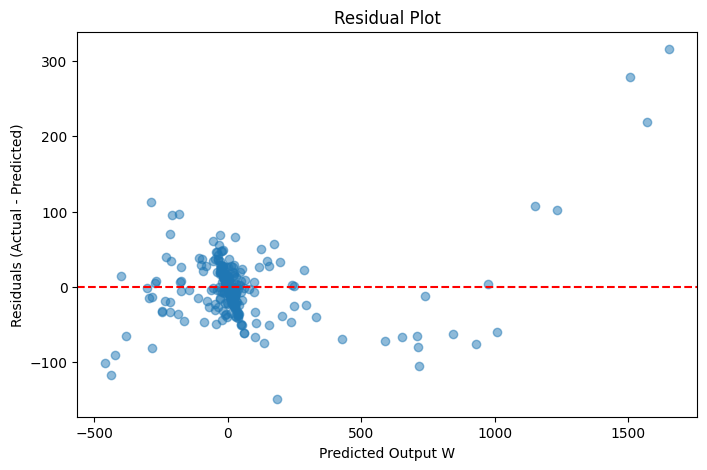

In [10]:
import matplotlib.pyplot as plt

residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Output W')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot')
plt.show()